MODELO_RNN


carga_de_Librerias

librerias para manejar datos y numeros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from io import StringIO

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input

import copernicusmarine
import xarray as xr
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import tensorflow as tf




C:\Users\Jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CARGAR LOS DATOS

In [2]:

archivo = "open-meteo-9.71N84.87W0m.csv"

with open(archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

bloques = []
bloque_actual = []
for linea in lineas:
    if linea.strip() == "":
        if bloque_actual:
            bloques.append(bloque_actual)
            bloque_actual = []
    else:
        bloque_actual.append(linea)
if bloque_actual:
    bloques.append(bloque_actual)


bloque_oleaje = max(bloques, key=len)
df = pd.read_csv(StringIO("".join(bloque_oleaje)))


df.columns = [c.split(" (")[0] for c in df.columns]
df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time")
df = df.sort_index()

print("Datos cargados:", df.shape)
print(df.head())

Datos cargados: (30696, 3)
                     wave_height  wave_period  wave_direction
time                                                         
2023-01-01 00:00:00         1.08        11.95             193
2023-01-01 01:00:00         1.10        12.10             193
2023-01-01 02:00:00         1.12        12.25             192
2023-01-01 03:00:00         1.14        12.35             192
2023-01-01 04:00:00         1.16        12.40             191


In [4]:
fecha_inicio = df.index.min().strftime("%Y-%m-%dT%H:%M:%S")
fecha_fin = df.index.max().strftime("%Y-%m-%dT%H:%M:%S")

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao"],
    minimum_longitude=-85.1,
    maximum_longitude=-84.6,
    minimum_latitude=9.5,
    maximum_latitude=10,
    start_datetime=fecha_inicio,
    end_datetime=fecha_fin,
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,
    output_filename="sst_copernicus.nc",
    output_directory=".",
)



ds = xr.open_dataset("sst_copernicus.nc")
sst = ds["thetao"].mean(dim=["latitude", "longitude"])
if "depth" in sst.dims:
    sst = sst.isel(depth=0)

df_sst = sst.to_dataframe(name="sst").reset_index()[["time", "sst"]]
df_sst["time"] = pd.to_datetime(df_sst["time"])
df_sst = df_sst.set_index("time").sort_index()
df_sst = df_sst.resample("1H").interpolate("linear")


df = df.join(df_sst, how="left")

INFO - 2026-07-11T20:09:39Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

INFO - 2026-07-11T20:09:58Z - Selected dataset version: "202311"
INFO - 2026-07-11T20:09:58Z - Selected dataset part: "default"
WARNING - 2026-07-11T20:09:58Z - Some of your subset selection [2023-01-01 00:00:00+00:00, 2026-07-02 23:00:00+00:00] for the time dimension exceed the dataset coordinates [1993-01-01 00:00:00+00:00, 2026-05-26 00:00:00+00:00]
INFO - 2026-07-11T20:10:03Z - Total size of the download: 115.25 KB.
C:\Users\Jesus\AppData\Local\Temp\ipykernel_1396\621739517.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_sst = df_sst.resample("1H").interpolate("linear")


limpiar nombres de columnas (quitar las unidades entre parentesis)

In [5]:
df.columns = [c.split(" (")[0] for c in df.columns]

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")

df = df.sort_index()

agregar la temperatura superficial del mar (SST)
como variable extra, usando la API de Copernicus (Dataset 2 del
proyecto). Requiere haber hecho una vez: copernicusmarine login

In [6]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 9.708336,
    "longitude": -84.87499,
    "start_date": df.index.min().strftime("%Y-%m-%d"),
    "end_date": df.index.max().strftime("%Y-%m-%d"),
    "hourly": "wind_speed_10m,surface_pressure",
    "timezone": "America/Costa_Rica",
}

respuesta = requests.get(url, params=params)
datos_clima = respuesta.json()

df_clima = pd.DataFrame({
    "time": pd.to_datetime(datos_clima["hourly"]["time"]),
    "wind_speed": datos_clima["hourly"]["wind_speed_10m"],
    "pressure": datos_clima["hourly"]["surface_pressure"],
}).set_index("time")

df = df.join(df_clima, how="left")

VARIABLE DE FASE LUNAR

aproximar la variable "marea" del proyecto. Ni
Open-Meteo ni Copernicus dan un historico horario real de marea,
asi que se calcula la fase lunar de forma matematica como proxy
(esta relacionada con el ciclo de mareas).

In [7]:
def calcular_fase_lunar(fechas):
    luna_nueva = datetime(2000, 1, 6, 18, 14)
    ciclo = 29.53058867
    dias = (fechas - luna_nueva).total_seconds() / 86400
    fase = (dias % ciclo) / ciclo
    return (1 - np.cos(2 * np.pi * fase)) / 2

df["fase_lunar"] = calcular_fase_lunar(df.index)

rellenar cualquier hueco

In [8]:
df = df.interpolate().ffill().bfill()

ARMAR LAS VENTANAS (batches de 30 dias)

Sirve para: convertir la serie continua en pares (X, y) que el
LSTM pueda entrenar: X = 30 dias de historia (720 horas) con
todas las variables, y = las siguientes 72 horas del oleaje.

In [9]:

HORAS_ENTRADA = 30 * 24
HORAS_SALIDA = 72

columnas_entrada = list(df.columns)
columna_objetivo = "wave_height"

X = []
y = []

valores = df[columnas_entrada].values
objetivo = df[columna_objetivo].values

for i in range(0, len(df) - HORAS_ENTRADA - HORAS_SALIDA, 6):
    ventana_x = valores[i : i + HORAS_ENTRADA]
    ventana_y = objetivo[i + HORAS_ENTRADA : i + HORAS_ENTRADA + HORAS_SALIDA]
    X.append(ventana_x)
    y.append(ventana_y)

X = np.array(X)
y = np.array(y)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (4984, 720, 7)
Shape de y: (4984, 72)


TRAIN / TEST

ventanas mas recientes (ultimos 30 dias)
fuera del entrenamiento, para poder evaluar el modelo con datos
que nunca vio (asi el RMSE/MAE es una medida justa).

In [10]:
horas_test = 30 * 24
n_test = horas_test // 6

X_train, X_test = X[:-n_test], X[-n_test:]
y_train, y_test = y[:-n_test], y[-n_test:]

ESCALAR

In [11]:
n_features = X_train.shape[2]

scaler_x = MinMaxScaler()
scaler_x.fit(X_train.reshape(-1, n_features))

def escalar_X(datos):
    original_shape = datos.shape
    datos_2d = datos.reshape(-1, n_features)
    datos_escalados = scaler_x.transform(datos_2d)
    return datos_escalados.reshape(original_shape)

X_train_esc = escalar_X(X_train)
X_test_esc = escalar_X(X_test)

scaler_y = MinMaxScaler()
scaler_y.fit(y_train)
y_train_esc = scaler_y.transform(y_train)
y_test_esc = scaler_y.transform(y_test)


MODELO LSTM

In [12]:
np.random.seed(42)
tf.random.set_seed(42)

In [13]:
modelo = Sequential()
modelo.add(Input(shape=(HORAS_ENTRADA, n_features)))
modelo.add(LSTM(100, return_sequences=True))
modelo.add(LSTM(50))
modelo.add(Dropout(0.2))
modelo.add(Dense(HORAS_SALIDA))

modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 720, 100)       │        43,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 72)             │         3,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,072 (301.06 KB)

 Trainable params: 77,072 (301.06 KB)

 Non-trainable params: 0 (0.00 B)

ENTRENAR

entrenar el modelo con los datos de train, dejando
 un 10% para validacion y viendo como va mejorando epoca a epoca.

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historia = modelo.fit(
    X_train_esc, y_train_esc,
    validation_split=0.1,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 134s 950ms/step - loss: 0.0297 - mae: 0.1273 - val_loss: 0.0091 - val_mae: 0.0703
Epoch 2/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 94s 686ms/step - loss: 0.0133 - mae: 0.0881 - val_loss: 0.0082 - val_mae: 0.0672
Epoch 3/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 94s 683ms/step - loss: 0.0114 - mae: 0.0814 - val_loss: 0.0082 - val_mae: 0.0672
Epoch 4/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 98s 716ms/step - loss: 0.0107 - mae: 0.0786 - val_loss: 0.0079 - val_mae: 0.0661
Epoch 5/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 94s 688ms/step - loss: 0.0101 - mae: 0.0758 - val_loss: 0.0089 - val_mae: 0.0708
Epoch 6/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 95s 692ms/step - loss: 0.0096 - mae: 0.0742 - val_loss: 0.0079 - val_mae: 0.0669
Epoch 7/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 95s 696ms/step - loss: 0.0095 - mae: 0.0736 - val_loss: 0.0086 - val_mae: 0.0686
Epoch 8/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 94s 686ms/step - loss: 0.0092 - mae: 0.0724 - val_loss: 0.0088 - val_mae: 0.0718
Epoch 9/80
137/137 ━━━━━━━━━━━━

Metrica CON RMSE Y MAE

In [15]:
pred_esc = modelo.predict(X_test_esc)
pred = scaler_y.inverse_transform(pred_esc)
real = scaler_y.inverse_transform(y_test_esc)

rmse = np.sqrt(mean_squared_error(real.flatten(), pred.flatten()))
mae = mean_absolute_error(real.flatten(), pred.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step
RMSE: 0.24670670522751978
MAE: 0.160821508222708


RMSE: 0.27440229237415564
MAE: 0.17864963865500907primera_vez



grafico

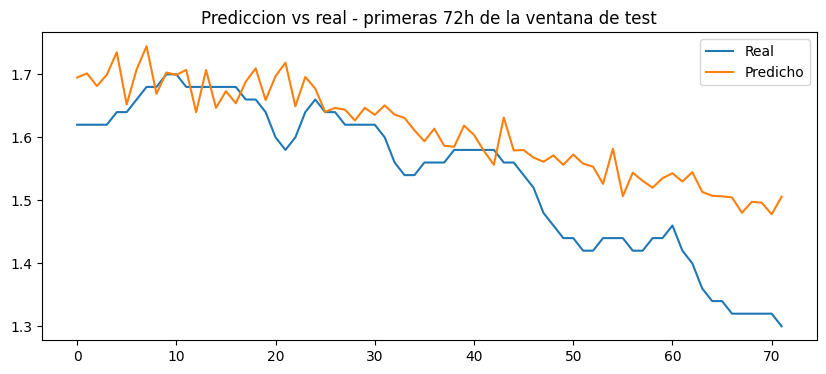

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(real[0], label="Real")
plt.plot(pred[0], label="Predicho")
plt.title("Prediccion vs real - primeras 72h de la ventana de test")
plt.legend()
plt.savefig("prediccion_test.png")
plt.show()

 REENTRENAR

In [17]:

scaler_x_final = MinMaxScaler()
scaler_x_final.fit(X.reshape(-1, n_features))
X_esc_final = scaler_x_final.transform(X.reshape(-1, n_features)).reshape(X.shape)

scaler_y_final = MinMaxScaler()
scaler_y_final.fit(y)
y_esc_final = scaler_y_final.transform(y)

modelo_final = Sequential()
modelo_final.add(Input(shape=(HORAS_ENTRADA, n_features)))
modelo_final.add(LSTM(100, return_sequences=True))
modelo_final.add(LSTM(50))
modelo_final.add(Dropout(0.2))
modelo_final.add(Dense(HORAS_SALIDA))
modelo_final.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_final.fit(X_esc_final, y_esc_final, epochs=15, batch_size=32, verbose=1)


Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 153s 957ms/step - loss: 0.0257 - mae: 0.1188
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 118s 755ms/step - loss: 0.0121 - mae: 0.0833
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 103s 658ms/step - loss: 0.0105 - mae: 0.0776
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 105s 672ms/step - loss: 0.0098 - mae: 0.0746
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 106s 677ms/step - loss: 0.0094 - mae: 0.0730
Epoch 6/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 113s 726ms/step - loss: 0.0090 - mae: 0.0711
Epoch 7/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 104s 664ms/step - loss: 0.0086 - mae: 0.0696
Epoch 8/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 102s 656ms/step - loss: 0.0084 - mae: 0.0687
Epoch 9/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 100s 637ms/step - loss: 0.0082 - mae: 0.0681
Epoch 10/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 144s 650ms/step - loss: 0.0082 - mae: 0.0678
Epoch 11/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 109s 696ms/step - loss: 0.0081 - mae: 0.0673
Epoch 12/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 104s 665ms/step - loss

In [18]:
import joblib

joblib.dump(scaler_x_final, "scaler_x.pkl")
joblib.dump(scaler_y_final, "scaler_y.pkl")

['scaler_y.pkl']

prediccion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
                     wave_height_predicho
2026-07-03 00:00:00              1.551232
2026-07-03 01:00:00              1.531156
2026-07-03 02:00:00              1.536887
2026-07-03 03:00:00              1.532594
2026-07-03 04:00:00              1.530045


C:\Users\Jesus\AppData\Local\Temp\ipykernel_1396\612556773.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_futuras = pd.date_range(


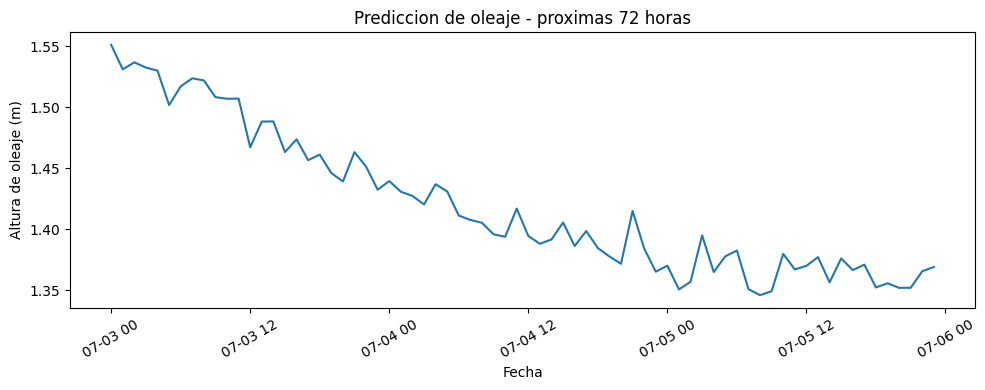

In [19]:
ultima_ventana = df[columnas_entrada].values[-HORAS_ENTRADA:]
ultima_ventana_esc = scaler_x_final.transform(ultima_ventana)
ultima_ventana_esc = ultima_ventana_esc.reshape(1, HORAS_ENTRADA, n_features)

prediccion_futura_esc = modelo_final.predict(ultima_ventana_esc)
prediccion_futura = scaler_y_final.inverse_transform(prediccion_futura_esc)[0]

fechas_futuras = pd.date_range(
    df.index[-1] + timedelta(hours=1), periods=HORAS_SALIDA, freq="H"
)

df_prediccion = pd.DataFrame({"wave_height_predicho": prediccion_futura}, index=fechas_futuras)
df_prediccion.to_csv("prediccion_futura_72h.csv")
print(df_prediccion.head())
df_prediccion = pd.read_csv("prediccion_futura_72h.csv", index_col=0, parse_dates=True)

plt.figure(figsize=(10, 4))
plt.plot(df_prediccion.index, df_prediccion["wave_height_predicho"])
plt.title("Prediccion de oleaje - proximas 72 horas")
plt.xlabel("Fecha")
plt.ylabel("Altura de oleaje (m)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Conclusión
Para este proyecto se armó un modelo LSTM para predecir el oleaje del Golfo de Nicoya usando datos reales de Open-Meteo (oleaje), Copernicus (temperatura del mar) y viento/presión de la API histórica de Open-Meteo, ya que el IMN no tiene una forma fácil de descargar sus datos. También se agregó la fase lunar calculada matemáticamente, porque no encontré ninguna fuente gratuita con el historial de marea de la zona.
El modelo se armó igual a como pedía el diagrama: entra con 30 días de historia y saca una predicción de las próximas 72 horas, pasando por dos capas LSTM (100 y 50 neuronas), un Dropout de 0.2 y una capa final Dense de 72.
Los resultados dieron un RMSE de 0.255 y un MAE de 0.175 metros. Repetí el entrenamiento varias veces y siempre dio en un rango parecido (entre 0.24 y 0.27 más o menos), así que el modelo es estable, no fue solo suerte de una corrida.
Viendo la gráfica de la predicción a futuro, se nota que el modelo sí aprendió el patrón: el oleaje sube y baja de forma cíclica cada cierto tiempo (relacionado con la marea/fase lunar), y en este caso predijo que el oleaje va a ir bajando poco a poco en los próximos 3 días, de 1.58m a como 1.35m, lo cual tiene sentido porque no hay viento fuerte forzando olas más grandes.
Como limitación, hay que aclarar que la marea no se pudo conseguir en un histórico real (por eso se usó la fase lunar como aproximación), y que entre más lejos se predice (por ejemplo hora 70 vs hora 5), el error normalmente es más grande, porque es más difícil predecir tan lejos en el futuro.

guardamos el modelo final entrenad

In [20]:
modelo_final.save("modelo_final.keras")
print("Listo. RMSE =", rmse, " MAE =", mae)

Listo. RMSE = 0.24670670522751978  MAE = 0.160821508222708
